### CorEx for anchored model topics with relevant seed-words
#robust seed version (see: PreTreatment\env_topics)

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from corextopic import corextopic as ct
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# robust seed topics for CorEx

topics = {
    "Manufacturing of low-carbon technologies": [
        "low-carbon technology manufacturing", "renewable energy equipment", "mitigation equipment", "energy-saving appliances",
        "clean-tech production", "photovoltaic module assembly", "wind turbine manufacturing", "EU Ecolabel",
        "Ecodesign Directive", "Energy Star", "IRENA", "SolarPower Europe",
        "technological lock-in", "subsidy dependence", "industrial competitiveness", "carbon leakage",
        "green industrial policy"
    ],

    "Energy efficiency in industrial processes": [
        "industrial energy performance", "heat recovery systems", "energy intensity reduction", "process optimization",
        "energy audits", "industrial thermal regulation", "high-efficiency motors", "ISO 50001",
        "ESCO", "IEA Industrial Energy", "Energy Efficiency First", "European Energy Efficiency Platform",
        "rebound effect", "abatement costs", "stranded industrial assets", "implementation gap",
        "investment barriers"
    ],

    "Circular material flows and material efficiency": [
        "circular material flows", "secondary raw materials", "design for disassembly", "material substitution",
        "by-product utilization", "remanufacturing processes", "industrial symbiosis", "Circular Economy Action Plan",
        "Waste Framework Directive", "Ellen MacArthur Foundation", "REACH regulation", "Cradle to Cradle",
        "downcycling", "recycling toxicity", "planned obsolescence", "waste trade",
        "recycled content claims"
    ],

    "Carbon Capture, Utilization, and Storage (CCU/CCS)": [
        "carbon capture storage", "geological sequestration", "direct air capture", "BECCS",
        "CCU technologies", "post-combustion capture", "underground storage integrity", "Global CCS Institute",
        "London Protocol", "CCS Directive", "Northern Lights Project", "IEA GHG",
        "unabated fossil fuels", "storage leakage risk", "moral hazard", "high operational cost",
        "CCS greenwashing"
    ],

    "Fuel switching and industrial electrification": [
        "industrial electrification", "low-emission hydrogen", "green ammonia", "industrial fuel switching",
        "electric arc furnaces", "synthetic kerosene", "industrial gas-to-power", "Hydrogen Council",
        "Power-to-X", "IPHE", "Green Hydrogen Catapult", "Clean Hydrogen Partnership",
        "hydrogen leakage", "grid capacity", "energy density", "hydrogen greenwashing",
        "electrification costs"
    ],

    "Sustainable mining for transition materials": [
        "critical minerals extraction", "lithium extraction", "rare earth elements", "tailings management",
        "mineral waste prevention", "deep-sea mining", "resource depletion", "Critical Raw Materials Act",
        "ICMM", "Responsible Mining Foundation", "OECD Mineral Guidelines", "Deep Sea Conservation Coalition",
        "habitat fragmentation", "resource curse", "indigenous land rights", "toxic tailings spill",
        "transition mineral rush"
    ],

    "Road transport electrification and battery technology": [
        "electric vehicles", "lithium-ion batteries", "charging infrastructure", "zero-emission vehicles",
        "vehicle-to-grid", "battery energy density", "liquid electrolyte", "IEA-STEPS",
        "Euro 7 standard", "International Energy Agency", "European Battery Alliance", "Global Battery Alliance",
        "range anxiety", "critical minerals", "battery resource footprint", "grid stability",
        "lithium scarcity"
    ],

    "Sustainable aviation and maritime fuels": [
        "sustainable aviation fuels", "e-kerosene", "bio-LNG", "maritime ammonia fuel",
        "hydrogen propulsion", "synthetic methanol", "fuel carbon intensity", "ICAO-CORSIA",
        "IMO GHG Strategy", "Clean Skies for Tomorrow", "Getting to Zero Coalition", "ReFuelEU Aviation",
        "food crop competition", "indirect land-use change", "refueling infrastructure", "biomass availability",
        "saf greenwashing"
    ],

    "Public transit systems and modal shift": [
        "public transit systems", "modal shift", "urban rail networks", "bus rapid transit",
        "active mobility infrastructure", "intermodal transport", "shared mobility", "UITP",
        "C40 Cities", "ITF", "Eltis", "SDG Target 11.2",
        "funding deficits", "car dependency", "urban sprawl", "last-mile connectivity",
        "transit exclusion"
    ],

    "Logistics and freight optimization": [
        "freight electrification", "rail freight optimization", "last-mile delivery efficiency", "modal integration",
        "eco-driving technologies", "automated platooning", "logistics hub energy efficiency", "Smart Freight Centre",
        "ALICE", "IEA Freight", "EU Sustainable and Smart Mobility",
        "fragmented supply chains", "empty runs", "delivery time pressures", "urban access restrictions",
        "freight cost margins"
    ],

    "Renewable energy integration and grid infrastructure": [
        "renewable energy integration", "smart grid infrastructure", "high-voltage direct current", "grid-scale storage",
        "demand-side response", "distributed energy resources", "interconnection capacity", "ENTSO-E",
        "IEA Grid", "IRENA Innovation", "Global Smart Grid Federation", "Clean Energy Ministerial",
        "curtailment rates", "grid congestion", "infrastructure costs", "cybersecurity risks",
        "permitting delays"
    ],

    "Nuclear energy deployment and safety": [
        "nuclear energy generation", "small modular reactors", "advanced nuclear technology", "nuclear waste management",
        "reactor decommissioning", "nuclear safety systems", "proliferation resistance", "IAEA",
        "World Nuclear Association", "OECD-NEA", "Euratom Treaty",
        "high capital costs", "radioactive waste disposal", "meltdown risk", "construction delays",
        "public opposition"
    ],

    "Fossil fuel phase-out and just transition": [
        "fossil fuel phase-out", "coal retirement mechanisms", "methane abatement from energy", "just transition funding",
        "subsidy reform", "repurposing oil infrastructure", "stranded fossil assets", "Powering Past Coal Alliance",
        "Just Transition Mechanism", "IEA Net Zero", "Extractive Industries Transparency Initiative", "Fossil Fuel Non-Proliferation Treaty",
        "economic dislocation", "energy security concerns", "lobbying pressure", "carbon lock-in",
        "re-skilling barriers"
    ],

    "Energy efficiency in buildings and appliances": [
        "building energy performance", "deep energy retrofits", "heat pump deployment", "smart building management",
        "energy-efficient appliances", "thermal insulation materials", "net-zero energy buildings", "WorldGBC",
        "IEA Buildings", "Energy Performance of Buildings Directive", "Global Alliance for Buildings and Construction",
        "split incentives", "high upfront retrofitting costs", "supply chain bottlenecks", "historic building constraints",
        "renovation rates"
    ],

    "Sustainable building materials and low-carbon design": [
        "low-carbon cement", "green steel structural design", "timber construction", "recycled aggregates",
        "life-cycle carbon assessment", "modular building components", "material circularity in construction", "Architecture 2030",
        "Cradle to Cradle Certified", "LEED certification", "BREEAM", "EU Level(s)",
        "embodied carbon metrics", "structural code barriers", "material cost premiums", "durability concerns",
        "demolition waste"
    ],

    "Urban density, green spaces, and resilient design": [
        "urban density optimization", "urban green infrastructure", "nature-based urban solutions", "heat island mitigation",
        "sustainable urban drainage", "walkable city design", "climate-resilient urban masterplans", "UN-Habitat",
        "ICLEI", "100 Resilient Cities", "New Urban Agenda", "SDG 11",
        "gentrification risks", "real estate speculation", "land-use conflicts", "maintenance funding",
        "urban sprawl pressures"
    ],

    "Sustainable agricultural practices and soil carbon management": [
        "regenerative agriculture", "conservation tillage", "cover cropping", "agroforestry systems",
        "soil carbon sequestration", "precision nutrient management", "organic farming standards", "FAO-GSP",
        "4per1000 initiative", "IFOAM", "EIT Food", "Common Agricultural Policy",
        "yield variability", "transition costs", "measurement uncertainty", "subsidy misalignment",
        "carbon credit permanence"
    ],

    "Methane mitigation and livestock management": [
        "enteric fermentation reduction", "manure management systems", "methane-inhibiting feed additives", "livestock herd management",
        "anaerobic digesters", "alternative protein sources", "dietary shifts", "Global Methane Pledge",
        "Climate and Clean Air Coalition", "FAO Livestock Environmental Assessment", "Methane Hub",
        "cultural diet resistance", "additive cost barriers", "smallholder economic constraints", "leakage to unmanaged sectors",
        "methane measurement difficulty"
    ],

    "Deforestation prevention and sustainable forestry": [
        "deforestation-free supply chains", "sustainable forest management", "reforestation initiatives", "afforestation programs",
        "forest degradation monitoring", "agro-silvopastoral systems", "certified timber production", "UN-REDD",
        "FSC", "PEFC", "New York Declaration on Forests", "EU Deforestation Regulation",
        "illegal logging", "land tenure insecurity", " leakage risks", "monoculture plantation impacts",
        "traceability costs"
    ],

    "Water resource management and climate adaptation": [
        "integrated water resources management", "efficient irrigation technologies", "wastewater reuse", "groundwater recharge",
        "water footprint reduction", "drought-resilient crop varieties", "watershed restoration", "Global Water Partnership",
        "UN-Water", "World Water Council", "Alliance for Water Stewardship", "SDG 6",
        "water scarcity conflicts", "transboundary water disputes", "infrastructure financing gaps", "subsidy-driven overuse",
        "climate-induced hydrological shifts"
    ],

    "Circular economy and solid waste management": [
        "extended producer responsibility", "zero waste strategies", "advanced sorting technologies", "mechanical recycling",
        "chemical recycling", "organic waste composting", "landfill gas capture", "Global Plastics Treaty",
        "ISWA", "Circular Economy Coalition", "UNEA resolutions", "SDG 12",
        "recycling contamination", "chemical recycling toxicity", "plastic production growth", "informal waste picker exclusion",
        "export of waste"
    ],

    "Clean water access and wastewater infrastructure": [
        "universal clean water access", "advanced wastewater treatment", "fecal sludge management", "decentralized sanitation systems",
        "water purification technologies", "sewerage network energy efficiency", "water loss reduction", "Water.org",
        "SWA", "IWA", "WHO/UNICEF JMP", "SDG 6.1 and 6.2",
        "infrastructure financing gaps", "affordability for vulnerable populations", "rural service sustainability", "industrial effluent contamination",
        "energy-intensive treatment"
    ],

    "Industrial water efficiency and pollution control": [
        "closed-loop industrial water systems", "zero liquid discharge", "industrial water recycling", "polluter pays enforcement",
        "heavy metal removal", "toxic effluent monitoring", "water-efficient industrial equipment", "UNIDO Water Management",
        "European Water Association", "EPA Effluent Guidelines", "Industrial Emissions Directive",
        "high compliance costs", "regulatory enforcement gaps", "legacy contamination sites", "technological capability constraints",
        "water quality data transparency"
    ],

    "Water-related disaster risk reduction": [
        "flood risk management", "early warning systems", "nature-based flood defense", "coastal storm surge protection",
        "disaster resilient water infrastructure", "drought management frameworks", "community-based disaster preparedness", "UNDRR",
        "Sendai Framework", "CREWS initiative", "Global Alliance for Disaster Risk Reduction", "SDG Target 11.5",
        "funding shortfalls", "inadequate meteorological data", "rapid urban coastal development", "maintenance backlogs",
        "transboundary early warning gaps"
    ],

    "Ocean and marine ecosystem protection": [
        "marine protected areas", "sustainable fisheries management", "bycatch reduction technologies", "marine litter prevention",
        "ocean acidification monitoring", "coral reef restoration", "mariculture sustainability", "UN Ocean Conference",
        "Ospat Commission", "Ocean Conservancy", "High Seas Treaty", "SDG 14",
        "illegal fishing (IUU)", "high seas enforcement gaps", "coastal run-off pollution", "climate-driven marine migration",
        "subsidies driving overfishing"
    ],

    "Terrestrial biodiversity and habitat conservation": [
        "terrestrial protected areas", "ecological corridor restoration", "habitat fragmentation prevention", "endangered species recovery",
        "invasive alien species control", "ecosystem services valuation", "indigenous-led conservation", "Kunming-Montreal Global Biodiversity Framework",
        "IUCN", "WWF", "Convention on Biological Diversity", "SDG 15",
        "land-use competition", "poaching pressures", "underfunded management", "conflicting agricultural subsidies",
        "climate-induced habitat shifts"
    ],

    "Soil biodiversity and agricultural degradation control": [
        "soil biota conservation", "microbial activity enhancement", "erosion control measures", "salinization prevention",
        "soil organic matter restoration", "sustainable pesticide reduction", "soil health monitoring", "Global Soil Biodiversity Initiative",
        "FAO Voluntary Guidelines for Sustainable Soil Management", "European Soil Data Centre", "EU Soil Strategy", "SDG Target 15.3",
        "chemical dependency lock-in", "short-term yield optimization", "soil degradation externalized costs", "lack of farmer incentives",
        "measurement standardization"
    ],

    "Freshwater ecosystem conservation": [
        "wetland restoration", "river connectivity preservation", "lake eutrophication control", "riparian zone management",
        "environmental flow tracking", "freshwater species protection", "peatland rewetting", "Ramsar Convention",
        "International Rivers", "Freshwater Action Network", "EU Water Framework Directive", "SDG Target 6.6",
        "dam construction impacts", "agricultural nutrient runoff", "urban encroachment", "invasive species dominance",
        "jurisdictional fragmentation"
    ],

    "Air quality management and urban pollution control": [
        "urban air quality monitoring", "low emission zones", "industrial particulate filtering", "smog reduction strategies",
        "clean household energy access", "ambient air standards enforcement", "non-road mobile machinery regulation", "WHO Air Quality Guidelines",
        "Climate and Clean Air Coalition", "Clean Air Task Force", "Euro standards", "SDG Target 3.9 and 11.6",
        "fossil fuel dependency", "transboundary air pollution", "monitoring network gaps", "automotive industry lobbying",
        "public health cost externalization"
    ],

    "Chemical safety and hazardous waste regulation": [
        "hazardous chemical substitution", "sound chemical management", "persistent organic pollutants elimination", "heavy metal exposure reduction",
        "chemical leasing models", "toxic waste disposal standards", "e-waste recycling safety", "Basel Convention",
        "Stockholm Convention", "Rotterdam Convention", "Strategic Approach to International Chemicals Management", "REACH",
        "illegal toxic waste dumping", "legacy chemical contamination", "data confidentiality barriers", "regulatory enforcement gaps",
        "informal recycling hazards"
    ],

    "Noise and light pollution mitigation": [
        "urban noise barriers", "quiet zone preservation", "low-noise road surfaces", "directional outdoor lighting",
        "dark sky protection", "light pollution zoning", "acoustic building insulation", "International Dark-Sky Association",
        "European Environment Agency Noise indicators", "WHO Environmental Noise Guidelines", "Eurocities Noise Working Group",
        "rapid urbanization", "24/7 economic activity", "lack of harmonized standards", "public awareness deficits",
        "enforcement low priority"
    ],

    "Environmental emergency response and remediation": [
        "oil spill response optimization", "industrial accident preparedness", "contaminated land remediation", "hazardous plume containment",
        "emergency response coordination", "bioremediation technologies", "post-disaster environmental assessment", "UNEP/OCHA Joint Environment Unit",
        "Remediation Technologies Screening Matrix", "Seveso Directive", "Superfund program",
        "liability avoidance", "remediation cost funding gaps", "delayed emergency response", "technical capacity deficits",
        "long-term ecological monitoring"
    ],

    "Climate change adaptation policy and governance": [
        "national adaptation plans", "climate risk disclosure", "climate vulnerability assessment", "local adaptation planning",
        "adaptation finance tracking", "multi-level climate governance", "institutional capacity building", "UNFCCC Adaptation Committee",
        "Global Center on Adaptation", "IPCC WGII", "EU Strategy on Adaptation", "SDG Target 13.1",
        "adaptation funding gap", "short-term political cycles", "siloed institutional structures", "uncertain climate projections",
        "maladaptation risks"
    ],

    "Infrastructure resilience and disaster risk reduction": [
        "resilient infrastructure standards", "critical asset protection", "nature-based risk reduction", "early warning systems integration",
        "disaster recovery frameworks", "climate-proofed utility networks", "seawall and coastal defense engineering", "UNDRR",
        "Sendai Framework", "Coalition for Disaster Resilient Infrastructure", "Global Platform for Disaster Risk Reduction", "SDG Target 9.a",
        "high upfront resilience costs", "maintenance funding deficits", "outdated engineering codes", "rapid uncoordinated urban expansion",
        "insurance market withdrawals"
    ],

    "Community-based adaptation and local knowledge": [
        "community-based adaptation", "indigenous climate knowledge", "local adaptation action", "participatory vulnerability mapping",
        "community-led asset protection", "traditional ecological farming", "local climate safety nets", "Global Hub on Indigenous Peoples",
        "CBA conference network", "IIED Local Action", "SDG Target 13.b",
        "marginalization of local voices", "funding access barriers", "top-down policy imposition", "loss of traditional practices",
        "scale-up constraints"
    ],

    "Ecosystem-based adaptation (EbA)": [
        "ecosystem-based adaptation", "nature-based climate solutions", "mangrove coastal protection", "watershed forest restoration",
        "urban green corridors for cooling", "agroecological microclimate management", "wetland flood retention", "EbA Community of Practice",
        "IUCN NbS Standard", "Global Ecosystem-based Adaptation Fund", "CBD Ecosystem Restoration",
        "slow realization of benefits", "land-use competition", "quantification of adaptation benefits", "institutional preference for gray infrastructure",
        "funding valuation challenges"
    ],

    "Resource efficiency and material decoupling": [
        "resource footprint reduction", "material decoupling metrics", "dematerialization strategies", "industrial eco-efficiency",
        "sustainable resource processing", "lifecycle material optimization", "sustainable extraction quotas", "International Resource Panel",
        "UNEP Resource Efficiency", "OECD Material Flows", "SDG Target 8.4 and 12.2",
        "rebound effects (Jevons paradox)", "linear business models", "extractive industry lobbying", "underpriced raw materials",
        "data collection gaps"
    ],

    "Eco-design and product lifetime extension": [
        "design for durability", "repairability indexes", "right to repair legislation", "upgradeable product design",
        "modular electronic architecture", "toxic substance substitution", "product-as-a-service models", "Ecodesign Sustainable Product Regulation",
        "The Restart Project", "iFixit European Network", "Ellen MacArthur Foundation Product Design",
        "planned obsolescence", "intellectual property restrictions", "consumer desire for novelty", "high repair costs",
        "spare parts availability"
    ],

    "Sustainable procurement and supply chain circularity": [
        "green public procurement", "sustainable supply chain management", "circular sourcing standards", "supplier environmental audits",
        "scope 3 material tracking", "take-back supply chain logistics", "recycled content verification", "Global Green Procurement Network",
        "ISO 20400", "Sustainable Purchasing Leadership Council", "EU GPP Criteria", "SDG Target 12.7",
        "higher initial procurement costs", "lack of supplier data transparency", "fragmented global supply chains", "small supplier resource constraints",
        "greenwashing in sourcing"
    ],

    "Industrial symbiosis and waste-to-resource networks": [
        "industrial symbiosis", "by-product exchange networks", "waste heat industrial utilization", "co-located manufacturing clusters",
        "shared industrial utility infrastructure", "inter-industry material cascading", "regional resource matching platforms", "EURIS",
        "International Industrial Symiosis Network", "European Circular Economy Stakeholder Platform", "GIZ Sustainable Industrial Areas",
        "regulatory waste definitions barriers", "inter-firm trust deficits", "transport costs of by-products", "unaligned production schedules",
        "contractual liability risks"
    ],

    "Occupational health and environmental hazard exposure": [
        "occupational environmental health", "workplace chemical safety", "industrial noise protection", "ergonomic environmental hazards",
        "worker heat stress prevention", "airborne hazard exposure control", "occupational disease tracking", "ILO Environmental Standards",
        "OSHA Environmental Hazards", "EU-OSHA", "WHO Occupational Health", "SDG Target 8.8",
        "underreporting of worker illness", "weak enforcement in informal sectors", "cost-cutting safety compliance", "corporate liability shield",
        "migrant worker exploitation"
    ],

    "Environmental justice and community health impacts": [
        "environmental justice", "fenceline community protection", "disproportionate pollution exposure", "community health monitoring",
        "environmental health inequities", "participatory environmental monitoring", "toxic trespass redress", "EJAtlas",
        "EPA Office of Environmental Justice", "Global Alliance on Health and Pollution", "Aarhus Convention", "SDG Target 16.7",
        "systemic political marginalization", "corporate legal resource asymmetry", "difficulty proving health causality", "lack of local air/water data",
        "economic blackmail"
    ],

    "Public health tracking of climate impacts": [
        "climate health surveillance", "heat-related mortality tracking", "vector-borne disease climate vectors", "extreme weather health registry",
        "mental health climate anxiety", "air pollution health impacts", "climate-resilient health systems", "Lancet Countdown on Health and Climate Change",
        "WHO Climate Change and Health", "CDC Climate and Health Program", "European Climate and Health Observatory",
        "siloed health and climate data", "underfunded public health systems", "attribution challenges", "vulnerable population tracking gaps",
        "geographic health surveillance disparities"
    ],

    "Chemical safety and consumer product toxicology": [
        "consumer product chemical safety", "endocrine disruptor screening", "toxic consumer exposure", "chemical transparency labeling",
        "biomonitoring studies", "safe-by-design consumer products", "children environmental health protection", "IPCP",
        "ChemSec", "EU Consumer Safety Regulation", "US CPSC Environmental",
        "trade secret chemical formulas", "slow regulatory toxicity testing", "regrettable chemical substitution", "lobbying by chemical brands",
        "global e-commerce enforcement gaps"
    ],

    "Environmental criteria in global financial regulation": [
        "green taxonomy integration", "climate financial risk disclosure", "double materiality frameworks", "sustainable finance regulations",
        "esg prudential requirements", "central bank green mandates", "sovereign green bond frameworks", "NGFS",
        "ISSB", "EU Sustainable Finance Disclosure Regulation", "TCFD",
        "greenwashing of financial assets", "fragmented national taxonomies", "data reliability deficits", "short-term financial optimization",
        "political pushback against ESG"
    ],

    "Corporate sustainability reporting and greenwashing prevention": [
        "corporate sustainability disclosures", "anti-greenwashing enforcement", "sustainability assurance standards", "scope 3 emissions disclosure",
        "materiality assessment auditing", "sustainability KPI verification", "corporate green claims regulation", "GRI",
        "Corporate Sustainability Reporting Directive", "SEC Climate Disclosure Rule", "Value Reporting Foundation",
        "compliance cost burden", "vague qualitative reporting", "supply chain data black boxes", "weak enforcement penalties",
        "consulting industry conflicts of interest"
    ],

    "Responsible investment and ESG integration": [
        "esg integration strategies", "responsible investment policies", "sustainability-themed investing", "shareholder environmental activism",
        "impact investing metrics", "fiduciary duty environmental interpretation", "esg rating methodology transparency", "UN PRI",
        "Ceres Investor Network", "Global Sustainable Investment Alliance", "Institutional Investors Group on Climate Change",
        "lack of rating standardization", "greenwashing by fund managers", "fiduciary duty legal challenges", "short-term performance metrics",
        "esg data coverage gaps"
    ],

    "Environmental liability and risk insurance": [
        "environmental liability insurance", "polluter pays enforcement tracking", "environmental remediation bonds", "climate risk underwritings",
        "natural catastrophe insurance pools", "environmental liability asset valuation", "corporate insolvency environmental provisions", "InsuResilience Global Partnership",
        "EU Environmental Liability Directive", "Geneva Association", "Principles for Sustainable Insurance",
        "uninsurable climate risks", "corporate bankruptcy liability evasion", "underestimating systemic climate risk", "insurance affordability crises",
        "data limitations for long-tail risks"
    ],

    "Renewable energy access and grid decentralization": [
        "decentralized energy access", "off-grid solar systems", "mini-grid deployment", "clean cooking solutions",
        "community energy ownership", "rural electrification programs", "poverty-alleviating energy policies", "Sustainable Energy for All",
        "IRENA Off-Grid", "GOGLA", "Clean Cooking Alliance", "SDG 7.1",
        "affordability barriers", "lack of maintenance infrastructure", "regulatory entry barriers", "financing risk premiums",
        "fossil fuel cooking subsidies"
    ],

    "Just transition and clean energy employment": [
        "clean energy job creation", "green skills training", "fossil fuel worker transition", "regional economic diversification",
        "fair labor green standards", "local community benefit agreements", "social protection green transition", "ILO Green Jobs",
        "Just Transition Centre", "European Just Transition Fund", "B Team", "SDG Target 8.5",
        "geographic mismatch of jobs", "wage disparities green vs fossil", "underfunded retraining programs", "loss of unionized workforce power",
        "community identity disruption"
    ],

    "Gender equity in environmental governance": [
        "gender-responsive environmental policy", "women land ownership rights", "gender climate vulnerability", "women environmental leadership",
        "gender-disaggregated environmental data", "inclusive natural resource management", "gender-green energy nexus", "UNFCCC Gender Action Plan",
        "WEDO", "IUCN Global Gender Office", "GGCA", "SDG Target 5.a and 13.b",
        "exclusion from decision-making", "entrenched patriarchal land laws", "underfunding of women organizations", "unequal domestic burden climate impacts",
        "gender-blind climate projects"
    ],

    "Indigenous rights and traditional land tenure": [
        "indigenous land titling", "free prior and informed consent", "traditional ecological knowledge", "indigenous co-management agreements",
        "territorial environmental protection", "indigenous climate leadership", "cultural heritage environmental preservation", "UNPFII",
        " Rights and Resources Initiative", "Amazon Basin Indigenous Organizations", "UN Declaration on the Rights of Indigenous Peoples", "SDG Target 15.6",
        "violent land encroachment", "legal framework gaps", "assassination of environmental defenders", "exclusion from international carbon markets",
        "paternalistic conservation models"
    ],

    "Environmental law enforcement and anti-corruption": [
        "environmental crime prosecution", "anti-corruption in resource allocation", "illegal wildlife trade interdiction", "environmental inspection capacity",
        "whistleblower environmental protection", "transnational environmental law enforcement", "timber traceability enforcement", "INTERPOL Environmental Security",
        "UNODC Global Programme on Environmental Crime", "Transparency International Environmental Governance", "EIA", "SDG Target 16.5",
        "bribery of enforcement officials", "weak judicial environmental penalties", "lack of cross-border enforcement coordination", "corporate capture of regulators",
        "defenders security risks"
    ],

    "Access to environmental information and justice": [
        "environmental data transparency", "public access environmental records", "citizen environmental litigation", "independent environmental impact assessment",
        "public consultation frameworks", "legal aid environmental cases", "protection of environmental defenders", "Aarhus Convention",
        "Escazu Agreement", "Access Initiative", "World Commission on Environmental Law", "SDG Target 16.10",
        "slapp suits by corporations", "state secrecy environmental security", "high cost of legal representation", "lack of independent data",
        "threats against activists"
    ],

    "International environmental treaty compliance": [
        "environmental treaty enforcement", "national compliance mechanisms", "international environmental dispute resolution", "multilateral environmental agreements tracking",
        "transboundary pollution dispute tracking", "global target reporting frameworks", "non-compliance penalty mechanisms", "UNFCCC Compliance Committee",
        "UNEP Environmental Law and Conventions", "Permanent Court of Arbitration Environmental", "InforMEA", "SDG Target 17.14",
        "lack of enforcement teeth", "national sovereignty geo-politics", "withdrawal from treaties", "weak domestic ratification",
        "reporting verification gaps"
    ],

    "Subnational environmental policy and city network coordination": [
        "subnational climate action", "city-level environmental regulations", "regional green cooperation", "municipal waste targets",
        "local ecological zoning", "subnational environmental finance", "city network green alliances", "C40 Cities Network",
        "ICLEI Local Governments", "Under2 Coalition", "Global Covenant of Mayors", "SDG Target 11.a",
        "unfunded municipal mandates", "jurisdictional conflicts state vs city", "limited local tax capacity", "political alignment shifts",
        "rural-urban resource conflicts"
    ],

    "Sustainable agricultural policy and smallholder support": [
        "smallholder sustainable support", "agroecological transition subsidies", "sustainable agricultural extension services", "fair market access for eco-products",
        "resilient smallholder supply chains", "rural green credit facilities", "cooperative sustainable farming models", "IFAD",
        "FAO Smallholders", "Via Campesina", "Global Alliance for Sustainable Agriculture", "SDG Target 2.3",
        "market dominance of agribusiness", "subsidy bias to industrial farming", "land consolidation pressures", "climate vulnerability smallholders",
        "lack of technical training"
    ],

    "Food waste reduction and circular food chains": [
        "food loss reduction", "circular urban food systems", "surplus food redistribution", "organic waste valorization",
        "cold chain infrastructure efficiency", "food waste tracking metrics", "consumer behavioral food waste campaigns", "Champions 12.3",
        "WRAP", "FAO Food Loss and Waste", "EU Platform on Food Losses and Food Waste", "SDG Target 12.3",
        "expiration date confusion", "retail cosmetic appearance standards", "uncoordinated distribution networks", "low disposal cost of food",
        "cold chain energy intensity"
    ],

    "Sustainable aquaculture and marine wild capture alignment": [
        "sustainable aquaculture certification", "recirculating aquaculture systems", "low-trophic aquaculture development", "traceable wild capture systems",
        "marine eco-labeling standards", "aquaculture nutrient pollution control", "artisanal fisheries protection", "FAO Code of Conduct for Responsible Fisheries",
        "MSC", "ASC", "Global Seafood Alliance", "SDG Target 14.7",
        "bycatch verification issues", "antibiotic overuse in aquaculture", "feed fish dependency", "mangrove clearance aquaculture",
        "forced labor in fishing fleets"
    ],

    "Genetic diversity protection and fair benefits sharing": [
        "agricultural genetic preservation", "fair and equitable benefit sharing", "seed bank infrastructure preservation", "equitable bioprospecting frameworks",
        "indigenous crop variety protection", "farmers rights to seeds", "nagoya protocol enforcement tracking", "Nagoya Protocol",
        "Global Crop Diversity Trust", "CBD Clearing-House", "FAO Plant Treaty", "SDG Target 2.5",
        "biopiracy by multinational firms", "patent lock-in of seeds", "loss of traditional seed knowledge", "regulatory complexity bioprospecting",
        "seed market monopolization"
    ],

    "Urban water security and infrastructure investment": [
        "urban water supply resilience", "water utility leakage reduction", "sustainable storm water management", "decentralized urban water systems",
        "smart water metering", "urban aquifer protection", "resilient drinking water systems", "World Bank Water",
        "IWA Sustainable Cities", "WaterAid Urban", "EU Urban Waste Water Directive", "SDG Target 11.6",
        "huge infrastructure financing gaps", "aging water pipe networks", "rapid un-piped urban growth", "water privatization conflicts",
        "climate-driven supply depletion"
    ],

    "Rural sanitation and hygiene access": [
        "safely managed rural sanitation", "community-led total sanitation", "hygiene infrastructure behavioral programs", "non-sewered sanitation systems",
        "school sanitation facilities access", "menstrual hygiene management infrastructure", "groundwater contamination prevention sanitation", "UNICEF Sanitation",
        "WSSCC", "Sustainable Sanitation Alliance", "Water Supply and Sanitation Collaborative Council", "SDG Target 6.2",
        "underfunded rural services", "cultural taboos hygiene behavioral change", "water scarcity sanitation limitations", "weak local government operation capacity",
        "disparate sparse population logistics"
    ],

    "Industrial water pollution enforcement and transparency": [
        "industrial effluent discharge tracking", "polluter disclosure transparency", "stringent industrial water fines", "real-time effluent monitoring",
        "toxic discharge public registry", "industrial water permit enforcement", "clean water legal advocacy", "Cepa pollution tracking",
        "E-PRTR", "WRI Aqueduct", "China IPE pollution map", "SDG Target 6.3",
        "corrupt regulatory compliance masking", "weak environmental agency funding", "legal loopholes for old factories", "measurement tampering",
        "lack of public disclosure laws"
    ],

    "Transboundary water cooperation and hydro-politics": [
        "transboundary water agreements", "joint river basin management", "international water data sharing", "cross-border aquifer cooperation",
        "hydro-diplomacy mechanisms", "shared water dispute resolution", "equitable water allocation tracking", "UNECE Water Convention",
        "International Network of Basin Organizations", "Stockholm International Water Institute", "UNESCO-IHP", "SDG Target 6.5",
        "national security water secrecy", "upstream-downstream political power asymmetry", "climate-driven flow variability disputes", "unilateral dam building projects",
        "absence of legal treaties"
    ],

    "Sustainable tourism policies and local products": [
        "sustainable tourism certification", "local sourcing in tourism", "community-based tourism development", "eco-tourism standards enforcement",
        "cultural heritage tourism conservation", "tourism carrying capacity limits", "local economic retention tourism", "UN Tourism",
        "Global Sustainable Tourism Council", "Sustainable Tourism Programme", "Transformational Travel Council", "SDG Target 8.9 and 12.b",
        "leakage of tourism revenue", "overtourism eroding local cultures", "greenwashed eco-resorts", "seasonal employment volatility",
        "displacement of local communities"
    ],

    "Carbon footprint of tourism-related travel": [
        "tourism transport decarbonization", "aviation emission offsets tourism", "sustainable destination mobility", "rail tourism development",
        "cruise ship emission regulation", "long-haul tourism reduction strategies", "low-carbon tourist transport options", "Glasgow Declaration on Climate Action in Tourism",
        "Sustainable Travel International", "TRAST", "Fly Green Alliance", "SDG Target 12.c",
        "high growth in long-haul flights", "cruise line heavy fuel use", "destination dependence on aviation", "ineffective carbon offset schemes",
        "lack of alternative low-carbon regional rail"
    ],

    "Resource efficiency in the hospitality sector": [
        "hotel energy efficiency retrofits", "hospitality food waste reduction", "water-saving hotel systems", "single-use plastic bans hospitality",
        "green hotel architecture design", "sustainable linen management laundering", "circular procurement in hotels", "Sustainable Hospitality Alliance",
        "Green Key Global", "EarthCheck", "EU Ecolabel Tourist Accommodation", "SDG Target 12.5",
        "high upfront retrofitting costs", "guest luxury comfort expectations", "fragmented franchise ownership compliance", "laundering chemical water pollution",
        "short-term commercial leases"
    ],

    "Biodiversity integration in tourism development": [
        "tourism biodiversity impact assessment", "wildlife tourism ethics regulation", "nature-based tourism conservation fees", "habitat protection zoning tourist zones",
        "marine tourism reef protection", "indigenous-led nature guiding", "invasive species prevention tourist paths", "Linking Tourism & Conservation",
        "The International Ecotourism Society", "IUCN Tourism and Protected Areas", "Convention on Biological Diversity Tourism Guidelines", "SDG Target 15.a",
        "habitat fragmentation for resorts", "wildlife disturbance by tourists", "illegal wildlife souvenir trade", "enclosure of conservation areas",
        "unregulated cruise ship coastal damage"
    ],

    "E-waste management and critical material recovery": [
        "e-waste urban mining", "critical material recycling electronic", "producer take-back electronics", "informal e-waste formalization",
        "toxic components e-waste safe removal", "circular smartphone design", "certified electronic recycling standards", "Step Initiative",
        "Global E-waste Statistics Partnership", "Basel Action Network", "WEEE Forum", "SDG Target 12.4",
        "illegal e-waste exports to developing countries", "complex multi-material electronic disassembly", "low cost of virgin materials", "primitive toxic open-burning recycling",
        "consumer hoarding of obsolete electronics"
    ],

    "Extended Producer Responsibility (EPR) policy frameworks": [
        "extended producer responsibility fee structures", "eco-modulation of epr fees", "producer responsibility organizations transparency", "mandatory packaging take-back",
        "epr enforcement auditing", "closing the loop policy designs", "post-consumer material collection targets", "OECD EPR Guidance",
        "Expra", "Global EPR Innovation Network", "Ellen MacArthur EPR Statement", "SDG Target 12.8",
        "producer lobbying to lower fees", "pro tracking data gaps", "free-rider e-commerce sellers", "insufficient fees to cover collection",
        "lack of municipal harmonization"
    ],

    "Plastics circularity and alternative materials": [
        "food-grade recycled plastics", "bio-based compostable plastics", "mechanical plastic sorting automation", "plastic design for recyclability",
        "chemical recycling depolymerization", "microplastic leakage prevention manufacturing", "zero-plastic retail business models", "Global Plastics Pact Network",
        "Plastic Pollution Coalition", "Break Free From Plastic", "Ellen MacArthur New Plastics Economy", "SDG Target 14.1",
        "low price of virgin fossil plastic", "chemical recycling high carbon footprint", "greenwashed biodegradable claims", "additives preventing plastic recycling",
        "sorting infrastructure technology gaps"
    ],

    "Organic waste diversion and composting networks": [
        "municipal source-separated organics", "industrial-scale composting systems", "anaerobic digestion biogas integration", "compost quality standards heavy metals",
        "landfill organic bans enforcement", "urban community composting networks", "soil application of organic compost", "US Composting Council",
        "European Compost Network", "Bio-based Industries Consortium", "Global Alliance for Incinerator Alternatives", "SDG Target 11.6",
        "plastic contamination in organic streams", "odor control community opposition", "high transport cost of heavy wet waste", "lack of local agricultural markets",
        "methane leakage from poor compost piles"
    ],

    "Clean energy access and rural electrification technology": [
        "solar home systems", "isolated clean mini-grids", "pico-solar lanterns", "community-managed rural utilities",
        "productive use energy appliances", "pay-as-you-go solar financing", "hybrid hydro-solar rural mini-grids", "Alliance for Rural Electrification",
        "PRACTICAL ACTION energy", "Grounded in Energy Access Network", "Smarter Energy for Africa", "SDG Target 7.1",
        "high risk defaults remote users", "lack of technician supply chains", "grid encroachment uncertainty", "limited local productive energy use",
        "high battery replacement cost"
    ],

    "Just transition tracking and structural economic shifts": [
        "just transition performance metrics", "fossil fuel community investment funds", "green diversification indicators regional", "labor union clean energy pacts",
        "vulnerable worker tracking transition", "social dialogue green transition policy", "regional economic resilience planning", "Just Transition Research Collaborative",
        "Wuppertal Institute Just Transition", "European Corporate Just Transition Indicators", "ITUC Just Transition Centre", "SDG Target 8.2",
        "superficial checklist compliance corporate", "underfunded long-term regional transition", "resistance from fossil labor unions", "lack of granular community data",
        "tokenistic worker consultation"
    ],

    "Gender mainstreaming in national environmental policies": [
        "gender environmental action plans", "gender-budgeting in climate finance", "women agricultural extension access", "gender-balanced resource committees",
        "climate impact gender vulnerability metrics", "women green entrepreneurship training", "gender equality natural resources law", "UN Women Climate Change",
        "Gender CC - Women for Climate Justice", "IUCN Gender-Responsive Policy database", "GGCA Policy analysis", "SDG Target 5.c",
        "bureaucratic resistance gender mainstreaming", "lack of gender-disaggregated data metrics", "purely tokenistic policy text representation", "deep-seated cultural legal barriers",
        "underfunding gender focal points"
    ],

    "Indigenous land management and conservation partnerships": [
        "indigenous-declared conservation areas", "co-management ancestral territories", "traditional ecological knowledge verification", "indigenous land stewardship funding",
        "mapping indigenous customary lands", "indigenous rangers wildlife monitoring", "cultural land rights advocacy", "Indigenous Peoples of Africa Co-ordinating Committee",
        "Forest Peoples Programme", "Land Rights Now", "Amazon Conservation Team", "SDG Target 15.9",
        "state overriding customary land rights", "fortress conservation model conflicts", "lack of direct funding to indigenous groups", "corporate resource extraction pressures",
        "scientific validation asymmetry traditional knowledge"
    ],

    "Environmental crime taskforces and cross-border enforcement": [
        "transnational environmental taskforces", "illegal wildlife trade interdiction networks", "interpol purple notices environmental", "cross-border timber tracking databases",
        "anti-money laundering environmental crime tracking", "joint customs environmental operations", "environmental forensics species identification", "EnviroCrime Network",
        "Lusaka Agreement Task Force", "ASEAN Working Group on CITES and Wildlife Enforcement", "WCO Environment Programme", "SDG Target 16.a",
        "unequal jurisdictional legal definitions", "lack of state judicial priority for green crime", "porous cross-border enforcement regions", "corruption of border customs officials",
        "limited environmental forensic capacity"
    ],

    "Public disclosure laws and community right-to-know": [
        "pollutant release and transfer registers", "community environmental right to know laws", "mandatory corporate pollution disclosure", "accessible public environmental databases",
        "citizen science environmental air monitoring", "independent environmental audit disclosure", "freedom of information environmental requests", "E-PRTR network",
        "RTK NET", "Open Government Partnership Environmental Working Group", "World Resources Institute Access initiative", "SDG Target 16.10",
        "corporate lawsuit protection trade secrets", "overly complex unreadable data formats", "lengthy freedom of information processing delays", "lack of community internet access data",
        "intimidation of data-seeking communities"
    ],

    "Multilateral environmental agreements compliance monitoring": [
        "mea compliance tracking mechanisms", "independent satellite treaty verification", "national environmental reporting harmonization", "treaty non-compliance formal sanctions",
        "peer-review treaty compliance states", "transnational environmental dispute arbitration", "global convention target scorecards", "UNEP MEA compliance guidelines",
        "Vertic treaty verification", "Center for International Environmental Law treaty tracking", "Climate Action Tracker", "SDG Target 17.16",
        "voluntary reporting lack of verification", "geopolitical gridlock blocking sanctions", "under-resourced treaty secretariat compliance arms", "national data manipulation hiding failure",
        "lack of unified enforcement tribunal"
    ],

    "Structural economic transformation and beyond-GDP metrics": [
        "beyond gdp indicator frameworks", "genuine progress indicator implementation", "inclusive wealth index tracking", "natural capital national accounting",
        "decoupling economic growth material footprint", "wellbeing economy policy design", "ecological footprint national tracking", "Beyond GDP EU initiative",
        "Wellbeing Economy Alliance", "Green Growth Knowledge Partnership", "UN System of Environmental-Economic Accounting", "SDG Target 17.19",
        "entrenched institutional bias towards GDP", "complexity explaining multi-dimensional indicators", "financial sector resistance alternative metrics", "data collection lag natural capital",
        "political reluctance adopting growth-limiting caps"
    ],

    "Marine protected area networks and enforcement": [
        "marine protected area network design", "no-take marine reserve enforcement", "satellite tracking illegal fishing mpa", "community-managed marine areas",
        "vessel monitoring system mpa tracking", "marine corridor biodiversity protection", "mpa ecological connectivity metrics", "MPAtlas",
        "Global Ocean Alliance", "Blue Nature Alliance", "OceanMind", "SDG Target 14.5",
        "paper parks lack of active enforcement", "high cost open-ocean vessel patrolling", "conflict with artisanal fishers livelihoods", "climate-driven shifting marine habitat boundaries",
        "flags of convenience avoiding mpa laws"
    ],

    "Ecological corridors and landscape connectivity": [
        "transboundary ecological corridors", "wildlife crossing infrastructure engineering", "landscape connectivity mapping gis", "habitat fragmentation mitigation planning",
        "buffer zone ecological management", "linear infrastructure wildlife impact guidelines", "migratory pathway protection agreements", "IUCN Connectivity Conservation Specialist Group",
        "Center for Large Landscape Conservation", "CorridorDesign", "European Ecological Network", "SDG Target 15.5",
        "private property land fragmentation", "high cost wildlife bridge engineering", "conflicting transport infrastructure masterplans", "weak cross-border land zoning alignment",
        "climate-forced shifts corridor paths"
    ],

    "Table access and traditional knowledge documentation": [
        "table access", "genetic diversity maintenance", "wild relatives", "traditional knowledge rights",
        "plant gene banks", "Nagoya Protocol", "CGIAR", "Rome Declaration on Nutrition",
        "SDG 15.6", "Intergovernmental Oceanographic Commission", "biopiracy", "intellectual property barriers",
        "fair compensation", "traditional knowledge exclusion", "access barriers"
    ],

    "Poaching and illegal wildlife trafficking": [
        "poaching", "wildlife trafficking", "illegal wildlife trade", "protected species",
        "illegal wildlife products", "trafficking supply chains", "wildlife crime", "CITES",
        "INTERPOL Environmental Crime", "EU Action Plan against Wildlife Trafficking", "SDG Target 15.7", "United Nations Convention against Transnational Organized Crime",
        "ivory trade", "corrupt enforcement", "livelihood-vs-poaching", "illegal logging syndicates",
        "organized crime mining"
    ],

    "Land degradation neutrality and soil biodiversity": [
        "land degradation neutrality", "soil biodiversity", "desertification", "soil restoration",
        "remediation of contaminated sites", "soil organic carbon", "fertile land", "United Nations Convention to Combat Desertification",
        "Global Soil Partnership", "SDG Target 15.3", "ISO 14001", "Rio Declaration on Environment and Development",
        "land grabbing", "soil depletion", "chemical fertilizer impact", "unsustainable farming",
        "measuring soil carbon"
    ],

    "Blue carbon and coastal ecosystem management": [
        "blue carbon", "coastal ecosystems", "carbon sequestration", "mangrove forest protection",
        "seagrass meadows", "salt marshes", "high-carbon stocks", "Blue Carbon Initiative",
        "Ramsar Convention", "SROCC report", "SDG Target 14.2", "Global Peatlands Initiative",
        "coastal development pressure", "carbon credit leakage", "rising sea levels", "aquaculture conversion impacts",
        "measuring blue carbon"
    ]
}

In [ ]:
# Load the dataset

df = pd.read_csv("clean-snopes_checked_v02.csv")
articles = df["ArticleText"].astype(str).tolist()

In [ ]:
# model settings

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20000,   # adjust if needed
    min_df=3              # ignore very rare words
)
X = vectorizer.fit_transform(articles)
words = vectorizer.get_feature_names_out()

anchor_words = list(topics.values())
topic_names  = list(topics.keys())
n_topics     = len(anchor_words)

anchor_words = [[w.lower() for w in lst] for lst in anchor_words] # ensure lowercase for matches

model = ct.Corex(
    n_hidden=n_topics,
    words=words,
    seed=42
)

model.fit(
    X,
    words=words,
    anchors=anchor_words,
    anchor_strength=5
)

In [ ]:
# Main topics with top words and relevance scores

for i, name in enumerate(topic_names):
    topic_words = model.get_topics(topic=i, n_words=15)
    print(f"\n=== Topic {i}: {topic_names[i]} ===")
    for word, score, _ in topic_words:   
        print(f"{word:20s} {score:.3f}") # ignoring the 3rd value


=== Topic 0: Energy ===
energy               0.130
carbon               0.086
nuclear              0.086
green                0.075
work                 0.056
page                 0.051
describes            0.050
customers            0.046
private              0.044
press                0.044
solar                0.043
information          0.043
engineer             0.043
machine              0.043
account              0.042

=== Topic 1: Transportation ===
urban                0.327
islands              0.065
states               0.063
largest              0.046
40                   0.045
coast                0.044
41                   0.043
play                 0.040
national             0.039
leaving              0.038
pattern              0.035
observed             0.035
acquired             0.035
adopt                0.035
putting              0.035

=== Topic 2: Agriculture & Food ===
farming              0.075
organic              0.042
pesticide            0.039
asking        

In [ ]:
for i, name in enumerate(topic_names):
    print(f"\n=== Topic {i}: {name} ===")    
    topic_words = model.get_topics(topic=i, n_words=3)  #top 3 words    
    for word, score, _ in topic_words:
        print(f"{word:20s} {score:.3f}")


=== Topic 0: Energy ===
energy               0.130
carbon               0.086
nuclear              0.086

=== Topic 1: Transportation ===
urban                0.327
islands              0.065
states               0.063

=== Topic 2: Agriculture & Food ===
farming              0.075
organic              0.042
pesticide            0.039

=== Topic 3: Climate Policy ===
green                0.389
left                 0.082
used                 0.081

=== Topic 4: Conservation & Land Use ===
wildlife             0.174
going                0.117
public               0.095

=== Topic 5: Water ===
conservatives        0.041
signing              0.036
remarks              0.036

=== Topic 6: Waste & Circular Economy ===
biggest              0.077
american             0.066
people               0.065


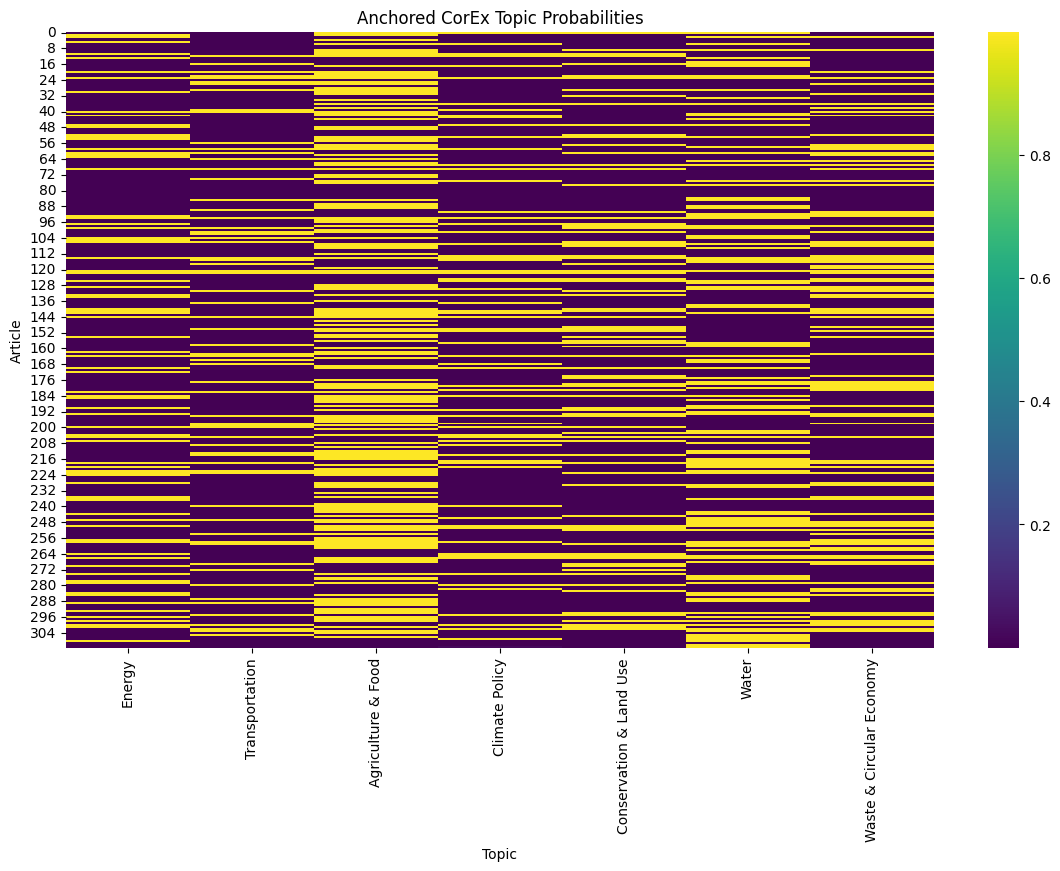

In [ ]:
# Visualizing topics in each article

labels = model.labels          #0/1
probs  = model.p_y_given_x      #probabilities

for i, name in enumerate(topic_names):
    df[f"CorEx_{name}_label"] = labels[:, i]
    df[f"CorEx_{name}_prob"]  = probs[:, i]

plt.figure(figsize=(14, 8))
sns.heatmap(probs, cmap="viridis", xticklabels=topic_names)
plt.xlabel("Topic")
plt.ylabel("Article")
plt.title("Anchored CorEx Topic Probabilities")
plt.show()